# BSAN391 -- Curve fitting -- CCC

In [1]:
# Appropriate imports
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.optimize import curve_fit

In [2]:
# Define the desired functional form
def functional_form(p, beta1, beta2):
    return beta1*(p**beta2)

In [3]:
# Data
p = np.array([1, 2, 3, 4, 5, 6, 9, 11, 14, 17, 19, 20])
q = np.array([42, 25, 17.8, 17.4, 19.5, 13, 13.1, 8, 9.2, 6.3, 7.9, 6.6])

In [4]:
# Fit --> popt: array of estimated values for the parameters
popt = curve_fit(functional_form, p, q)[0]

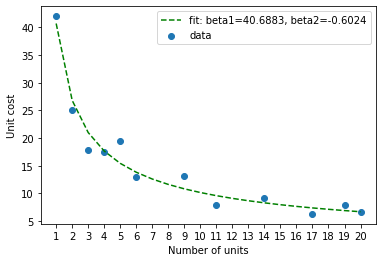

In [5]:
p_to_plot = [i for i in range(1,21)]
plt.scatter(p, q, label='data')
plt.plot(p_to_plot, functional_form(p_to_plot, *popt), 'g--',
         label='fit: beta1=%5.4f, beta2=%5.4f' % tuple(popt))
plt.xlabel('Number of units')
plt.ylabel('Unit cost')
plt.xticks(p_to_plot)
plt.legend()
plt.show()

In [6]:
# Returns the sum of squares of the residuals for a pair parameters beta1 and beta2
def least_squares_function(beta1,beta2,p,q):
    return sum((q[i] - beta1*(p[i]**beta2))**2 for i in range(len(p)))

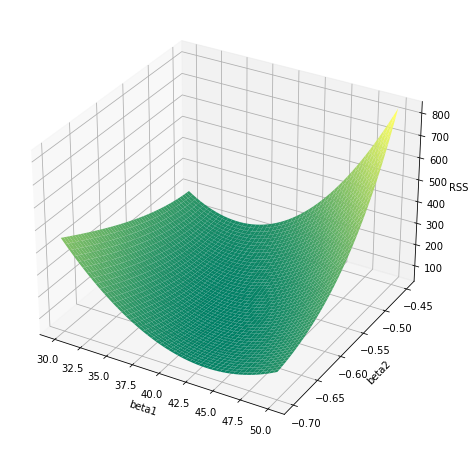

In [7]:
# Graphic representation of objective function
N = 1000
plt.rcParams['figure.figsize'] = (8,8)
beta1_values = np.linspace(30,50,N)
beta2_values = np.linspace(-0.7,-0.45,N)
beta1_grid, beta2_grid = np.meshgrid(beta1_values, beta2_values)
LS = least_squares_function(beta1_grid,beta2_grid,p,q)
ax = plt.axes(projection = '3d')
ax.set_xlabel('beta1')
ax.set_ylabel('beta2')
ax.set_zlabel('RSS')
ax.plot_surface(beta1_grid, beta2_grid, LS, cmap=cm.summer);